# Fase 01 — Preparación de datos y análisis exploratorio (EDA)

Este cuaderno documenta la preparación y el análisis exploratorio de las dos series de tráfico horario
disponibles al inicio del TP Final: el conteo total de solicitudes del *load balancer* (`alb`) y el conteo
de solicitudes por *target* del grupo `store-service` (`store_service`). El objetivo es dejar una serie
limpia y reproducible para cada métrica, junto con la evidencia empírica (estacionalidad, estacionariedad,
efecto de feriados, relación cruzada entre series) que justifica las decisiones de modelado de las fases
siguientes.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss, ccf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from tsa_final.data import (
    SERIES_REGISTRY,
    STEADY_STATE_START,
    INTERVENTION_START,
    INTERVENTION_END,
    TEST_START,
    TEST_END,
    LOCAL_TZ,
    load_raw,
    load_clean,
    intervention_mask,
    calendar_features,
)

sns.set_theme(style="whitegrid")
FIG_DIR = Path.cwd().parent / "informe" / "figuras"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SERIES_LABELS = {"alb": "ALB (RequestCount total)", "store_service": "store-service (RequestCountPerTarget)"}
SERIES_NAMES = list(SERIES_REGISTRY.keys())


def es_thousands(ax, axis="y"):
    """Format the given axis with '.' as thousands separator (Spanish convention)."""
    formatter = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
    getattr(ax, f"set_{axis}ticklabels")  # no-op, keeps flake8 quiet about axis var
    if axis == "y":
        ax.yaxis.set_major_formatter(formatter)
    else:
        ax.xaxis.set_major_formatter(formatter)


def savefig(fig, name):
    path = FIG_DIR / f"01_{name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"Figura guardada: {path.relative_to(Path.cwd().parent)}")


## 1. Serie cruda: rampa de arranque e inicio de régimen estable

Figura guardada: informe/figuras/01_raw_ramp.png


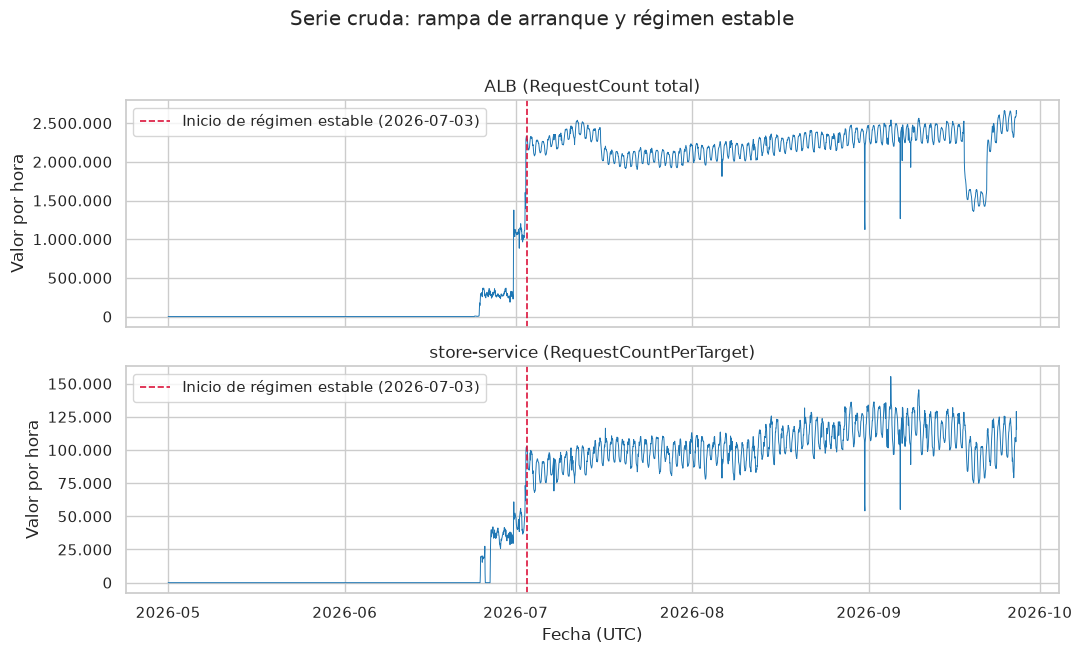

In [2]:
raw_series = {}
clean_series = {}
for name in SERIES_NAMES:
    raw_series[name] = load_raw(name)
    clean_series[name] = load_clean(name, impute=True)

fig, axes = plt.subplots(len(SERIES_NAMES), 1, figsize=(11, 3.2 * len(SERIES_NAMES)), sharex=True)
for ax, name in zip(axes, SERIES_NAMES):
    s = raw_series[name]
    ax.plot(s.index, s.values, linewidth=0.7, color="#1f77b4")
    ax.axvline(STEADY_STATE_START, color="crimson", linestyle="--", linewidth=1.2,
               label="Inicio de régimen estable (2026-07-03)")
    ax.set_title(SERIES_LABELS[name])
    ax.set_ylabel("Valor por hora")
    es_thousands(ax)
    ax.legend(loc="upper left")
ax.set_xlabel("Fecha (UTC)")
fig.suptitle("Serie cruda: rampa de arranque y régimen estable", y=1.02)
fig.tight_layout()
savefig(fig, "raw_ramp")
plt.show()

Antes de 2026-06-26 12:00 UTC el *load balancer* no existía y ambas series son cero. Entre esa fecha y
2026-07-03 se observa la rampa de arranque (el tráfico de ALB crece de aproximadamente 7 millones a 53
millones de solicitudes por día). A partir de 2026-07-03 00:00 UTC (`STEADY_STATE_START`) el nivel se
estabiliza y se considera el inicio del tramo utilizable para el modelado.

## 2. Serie limpia: ventana de intervención e imputación

Figura guardada: informe/figuras/01_intervention_zoom.png


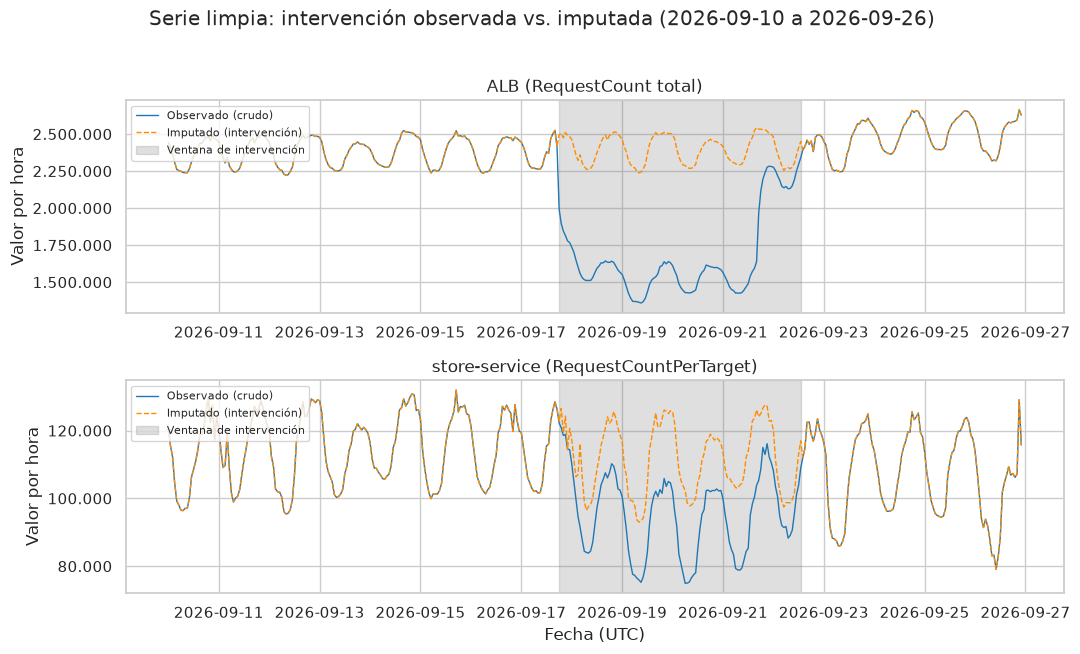

In [3]:
zoom_start = pd.Timestamp("2026-09-10", tz="UTC")
zoom_end = pd.Timestamp("2026-09-27", tz="UTC")

fig, axes = plt.subplots(len(SERIES_NAMES), 1, figsize=(11, 3.2 * len(SERIES_NAMES)), sharex=False)
for ax, name in zip(axes, SERIES_NAMES):
    raw = raw_series[name].loc[STEADY_STATE_START:]
    imputed = clean_series[name]
    zoom_raw = raw.loc[zoom_start:zoom_end]
    zoom_imputed = imputed.loc[zoom_start:zoom_end]
    ax.plot(zoom_raw.index, zoom_raw.values, label="Observado (crudo)", color="#1f77b4", linewidth=1.0)
    ax.plot(zoom_imputed.index, zoom_imputed.values, label="Imputado (intervención)", color="darkorange",
            linewidth=1.0, linestyle="--")
    ax.axvspan(INTERVENTION_START, INTERVENTION_END, color="grey", alpha=0.25, label="Ventana de intervención")
    ax.set_title(SERIES_LABELS[name])
    ax.set_ylabel("Valor por hora")
    es_thousands(ax)
    ax.legend(loc="upper left", fontsize=8)
axes[-1].set_xlabel("Fecha (UTC)")
fig.suptitle("Serie limpia: intervención observada vs. imputada (2026-09-10 a 2026-09-26)", y=1.02)
fig.tight_layout()
savefig(fig, "intervention_zoom")
plt.show()

La intervención conocida (2026-09-17 18:00 a 2026-09-22 13:00 UTC, 116 h) corresponde a un despliegue que
modificó el comportamiento de los clientes y luego se revirtió. Durante esa ventana, ALB cae a
aproximadamente el 72&nbsp;% del mismo horario de la semana anterior y `store_service` al 80-90&nbsp;%. La
serie limpia reemplaza esas 116 horas por el valor de `t-168h` corregido por un factor de nivel
(`impute_intervention`, ver docstring), preservando la forma horaria de la semana previa. Tras el rollback,
`store_service` queda de forma sostenida ~7&nbsp;% por debajo de la semana anterior (probable cambio de
nivel por el número de *targets* saludables); se trata como real y no se corrige.

## 3. Nivel medio semanal (tendencia)

Figura guardada: informe/figuras/01_weekly_level.png


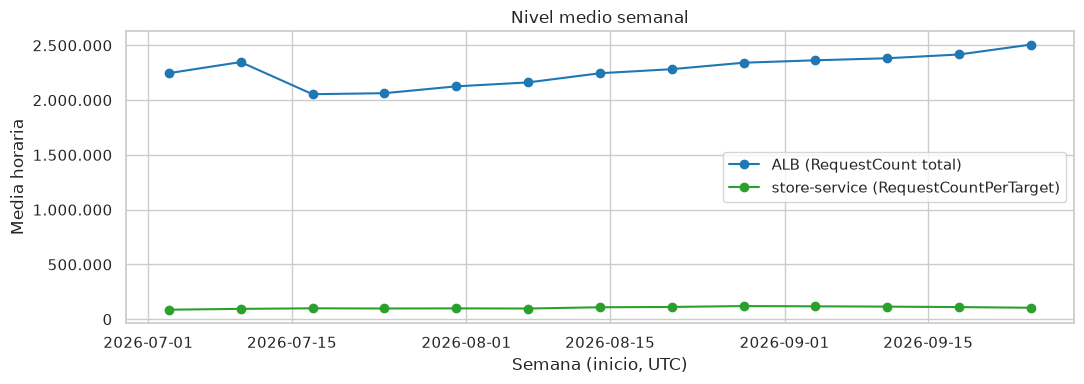

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
for name, color in zip(SERIES_NAMES, ["#1f77b4", "#2ca02c"]):
    weekly_mean = clean_series[name].resample("7D", origin=STEADY_STATE_START).mean()
    ax.plot(weekly_mean.index, weekly_mean.values, marker="o", label=SERIES_LABELS[name], color=color)
ax.set_title("Nivel medio semanal")
ax.set_xlabel("Semana (inicio, UTC)")
ax.set_ylabel("Media horaria")
es_thousands(ax)
ax.legend()
fig.tight_layout()
savefig(fig, "weekly_level")
plt.show()

El nivel medio semanal permite observar la tendencia de fondo a lo largo de las ~12 semanas de régimen
estable, más allá del efecto puntual de la intervención (ya corregida en la serie limpia).

## 4. Perfil horario en hora local, medias por día de semana y heatmap día×hora

--- ALB (RequestCount total) ---
Media por día de semana (hora local):
Lun    2239974.6
Mar    2252641.9
Mié    2264094.5
Jue    2265200.5
Vie    2279080.5
Sáb    2266663.8
Dom    2238448.0
Name: alb, dtype: float64
Rango relativo entre días de la semana: 1.80% de la media



Figura guardada: informe/figuras/01_hourly_profile_heatmap_alb.png


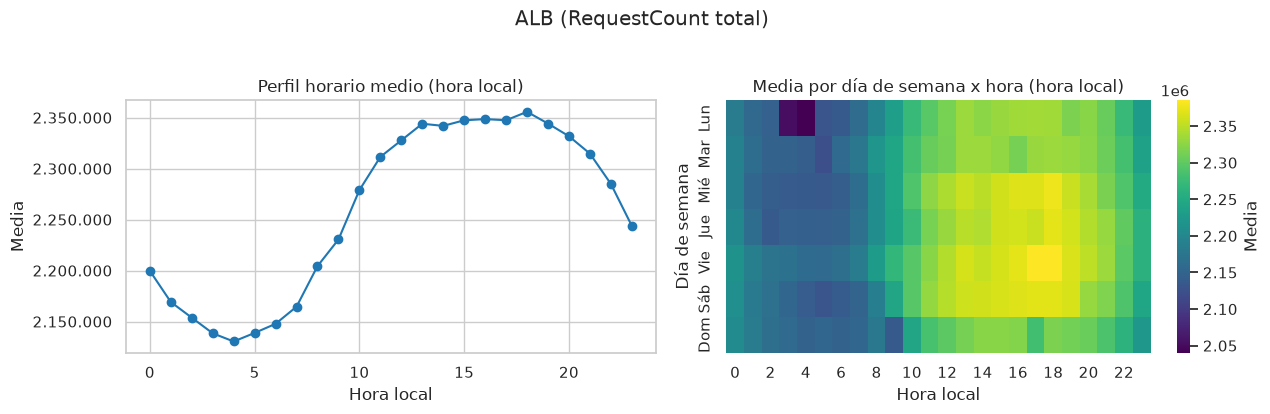

--- store-service (RequestCountPerTarget) ---
Media por día de semana (hora local):
Lun    104028.4
Mar    104867.6
Mié    105966.3
Jue    106460.0
Vie    106373.6
Sáb    103730.5
Dom    103435.3
Name: store_service, dtype: float64
Rango relativo entre días de la semana: 2.88% de la media



Figura guardada: informe/figuras/01_hourly_profile_heatmap_store_service.png


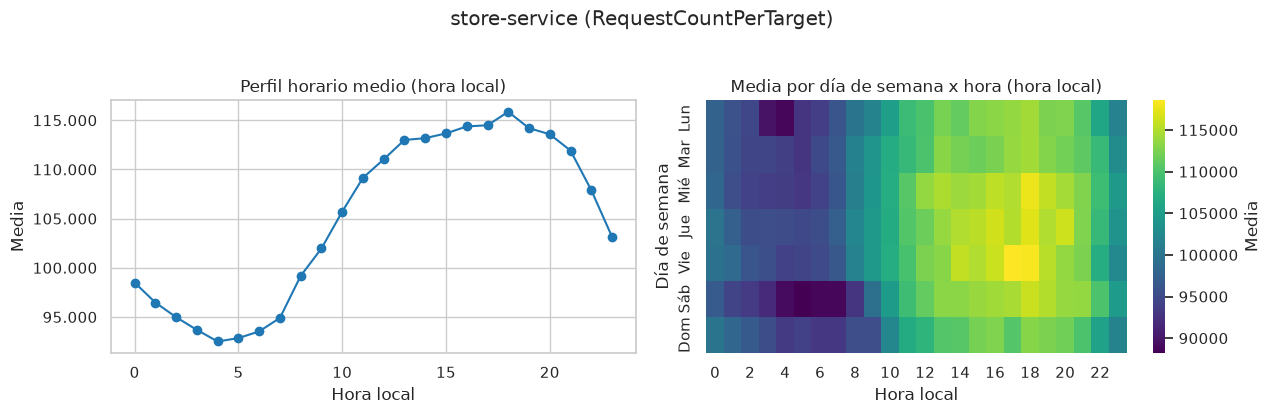

In [5]:
for name in SERIES_NAMES:
    s = clean_series[name]
    cf = calendar_features(s.index)
    local_index = s.index.tz_convert(LOCAL_TZ)

    hourly_profile = s.groupby(cf["hour"]).mean()
    weekday_means = s.groupby(cf["dayofweek"]).mean()
    weekday_means.index = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]

    print(f"--- {SERIES_LABELS[name]} ---")
    print("Media por día de semana (hora local):")
    print(weekday_means.round(1))
    rel_range = (weekday_means.max() - weekday_means.min()) / weekday_means.mean() * 100
    print(f"Rango relativo entre días de la semana: {rel_range:.2f}% de la media\n")

    heat_df = pd.DataFrame({"dow": cf["dayofweek"].values, "hour": cf["hour"].values, "value": s.values})
    heat_pivot = heat_df.pivot_table(index="dow", columns="hour", values="value", aggfunc="mean")
    heat_pivot.index = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(hourly_profile.index, hourly_profile.values, marker="o", color="#1f77b4")
    axes[0].set_title("Perfil horario medio (hora local)")
    axes[0].set_xlabel("Hora local")
    axes[0].set_ylabel("Media")
    es_thousands(axes[0])

    sns.heatmap(heat_pivot, cmap="viridis", ax=axes[1], cbar_kws={"label": "Media"})
    axes[1].set_title("Media por día de semana x hora (hora local)")
    axes[1].set_xlabel("Hora local")
    axes[1].set_ylabel("Día de semana")

    fig.suptitle(SERIES_LABELS[name], y=1.03)
    fig.tight_layout()
    savefig(fig, f"hourly_profile_heatmap_{name}")
    plt.show()

El perfil horario muestra un ciclo diario moderado (para ALB, aproximadamente entre 2,10 M/h a las 07 UTC
y 2,32 M/h en el horario nocturno, ±5&nbsp;%), con el mínimo a las 07 UTC equivalente a las 04:00 hora de
Argentina, consistente con el mínimo de actividad de los usuarios en horario local. Las medias por día de
semana difieren menos del 2&nbsp;% entre sí, y el heatmap día×hora no muestra un patrón semanal distinguible
más allá del ciclo diario: la estacionalidad semanal es prácticamente nula después de julio.

## 5. Descomposición MSTL (periodos 24 y 168) y fuerza de estacionalidad

Figura guardada: informe/figuras/01_mstl_alb.png


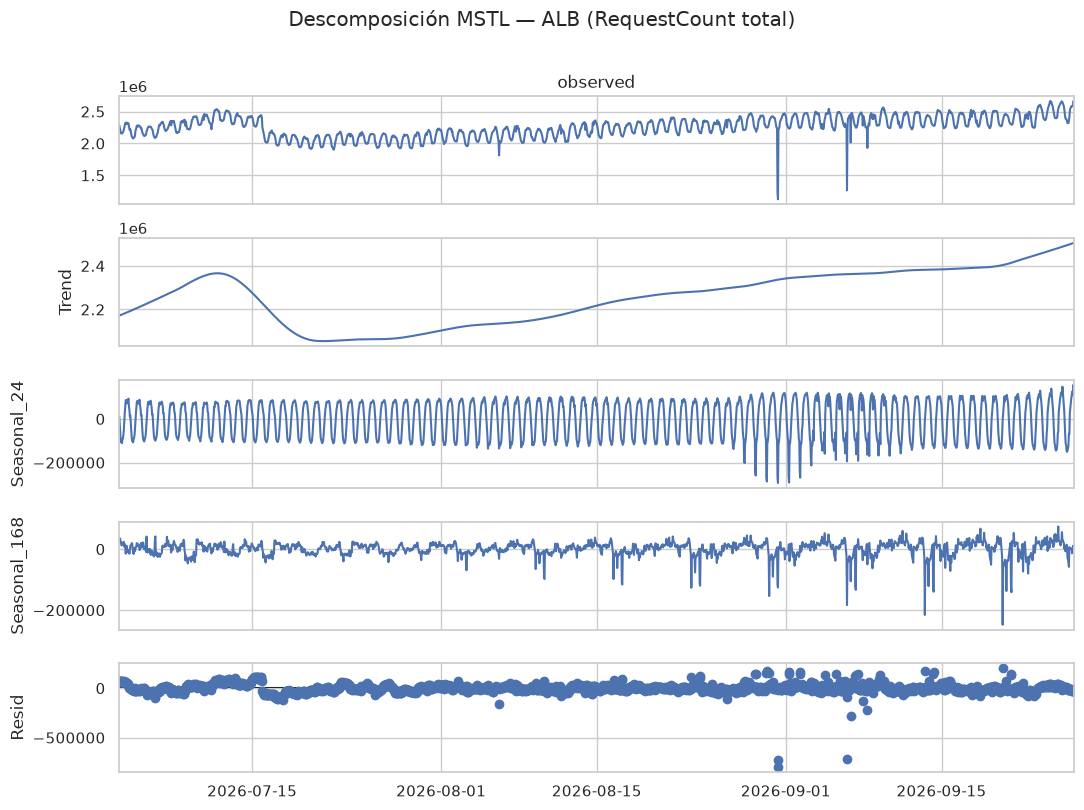

alb: fuerza estacional 24h = 0.771 | fuerza estacional 168h = 0.206 | fuerza de tendencia = 0.880


Figura guardada: informe/figuras/01_mstl_store_service.png


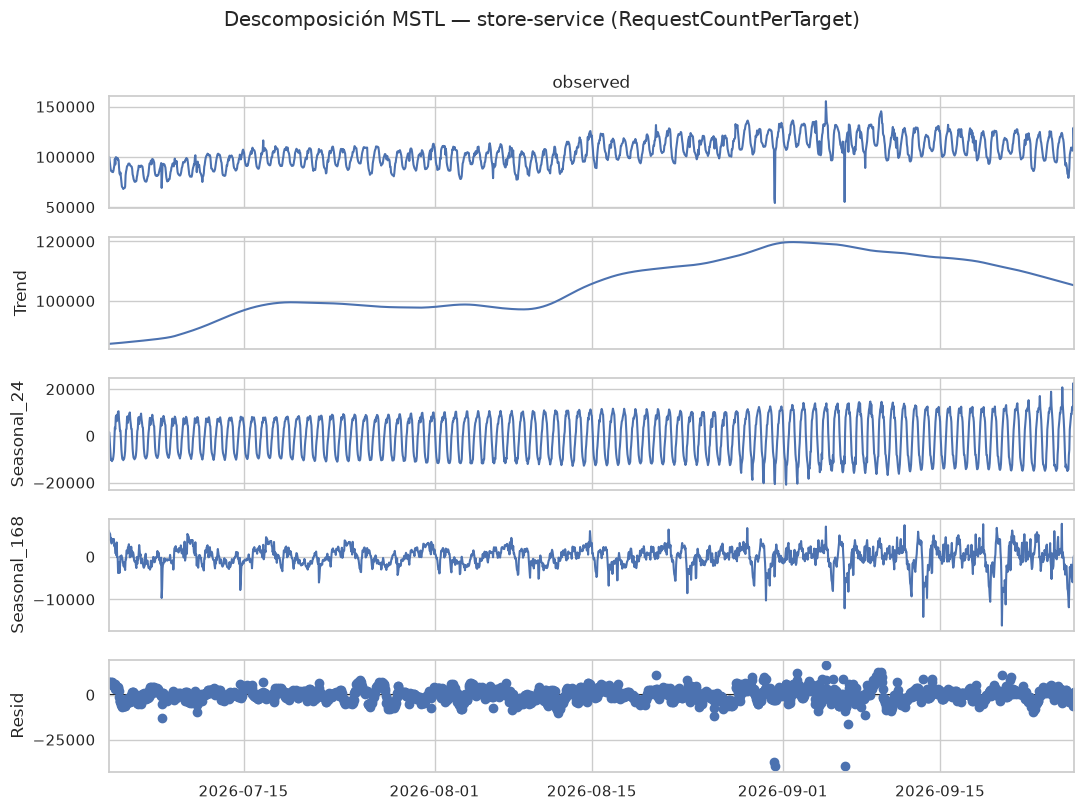

store_service: fuerza estacional 24h = 0.846 | fuerza estacional 168h = 0.311 | fuerza de tendencia = 0.876


In [6]:
mstl_results = {}
seasonality_strength = {}
for name in SERIES_NAMES:
    s = clean_series[name]
    mstl = MSTL(s, periods=(24, 168))
    res = mstl.fit()
    mstl_results[name] = res

    fig = res.plot()
    fig.set_size_inches(11, 8)
    fig.suptitle(f"Descomposición MSTL — {SERIES_LABELS[name]}", y=1.01)
    fig.tight_layout()
    savefig(fig, f"mstl_{name}")
    plt.show()

    trend, seasonal_24, seasonal_168, resid = (
        res.trend, res.seasonal["seasonal_24"], res.seasonal["seasonal_168"], res.resid
    )
    var_resid = resid.var()
    strength_24 = max(0.0, 1 - var_resid / (seasonal_24 + resid).var())
    strength_168 = max(0.0, 1 - var_resid / (seasonal_168 + resid).var())
    strength_trend = max(0.0, 1 - var_resid / (trend + resid).var())
    seasonality_strength[name] = {"s24": strength_24, "s168": strength_168, "trend": strength_trend}
    print(f"{name}: fuerza estacional 24h = {strength_24:.3f} | "
          f"fuerza estacional 168h = {strength_168:.3f} | fuerza de tendencia = {strength_trend:.3f}")

La fuerza de estacionalidad (según Wang, Smith & Hyndman) del componente de 24 h resulta muy superior a
la del componente de 168 h en ambas series, cuantificando lo observado en la sección anterior: el ciclo
diario es real pero moderado, y el componente semanal aporta muy poca varianza explicada adicional.

## 6. ACF / PACF hasta el lag 336

Figura guardada: informe/figuras/01_acf_pacf_alb.png


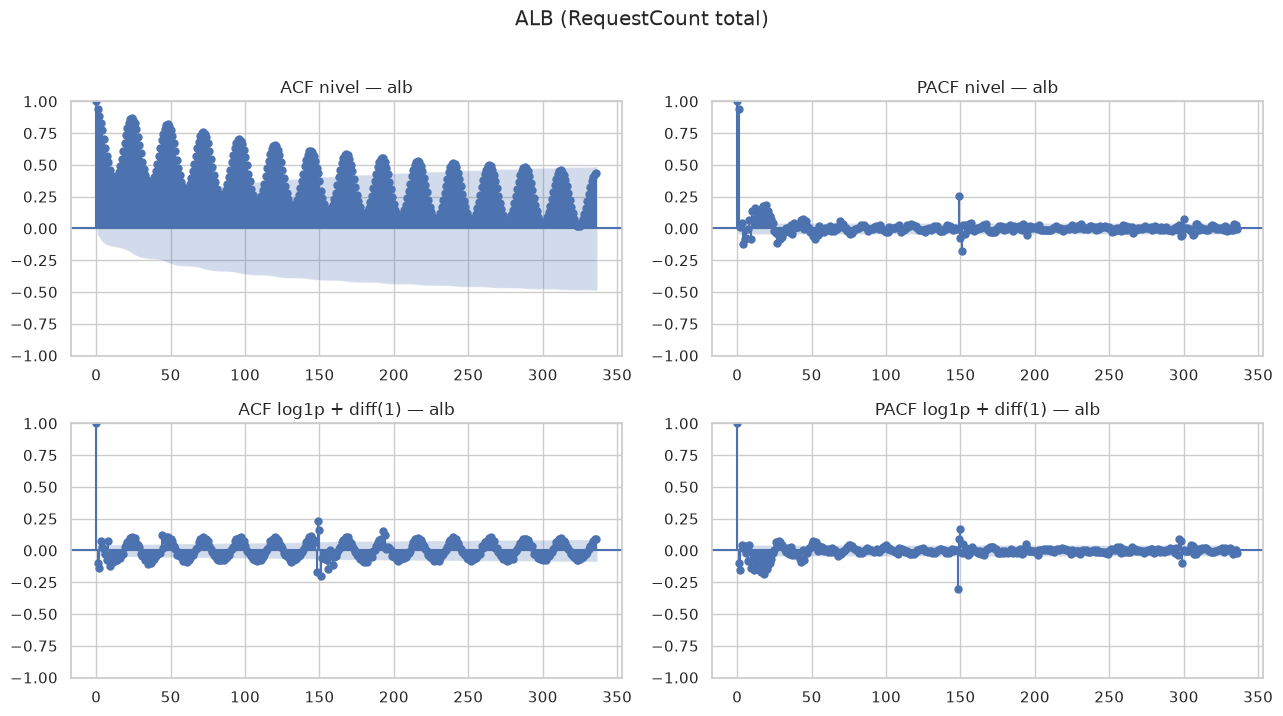

Figura guardada: informe/figuras/01_acf_pacf_store_service.png


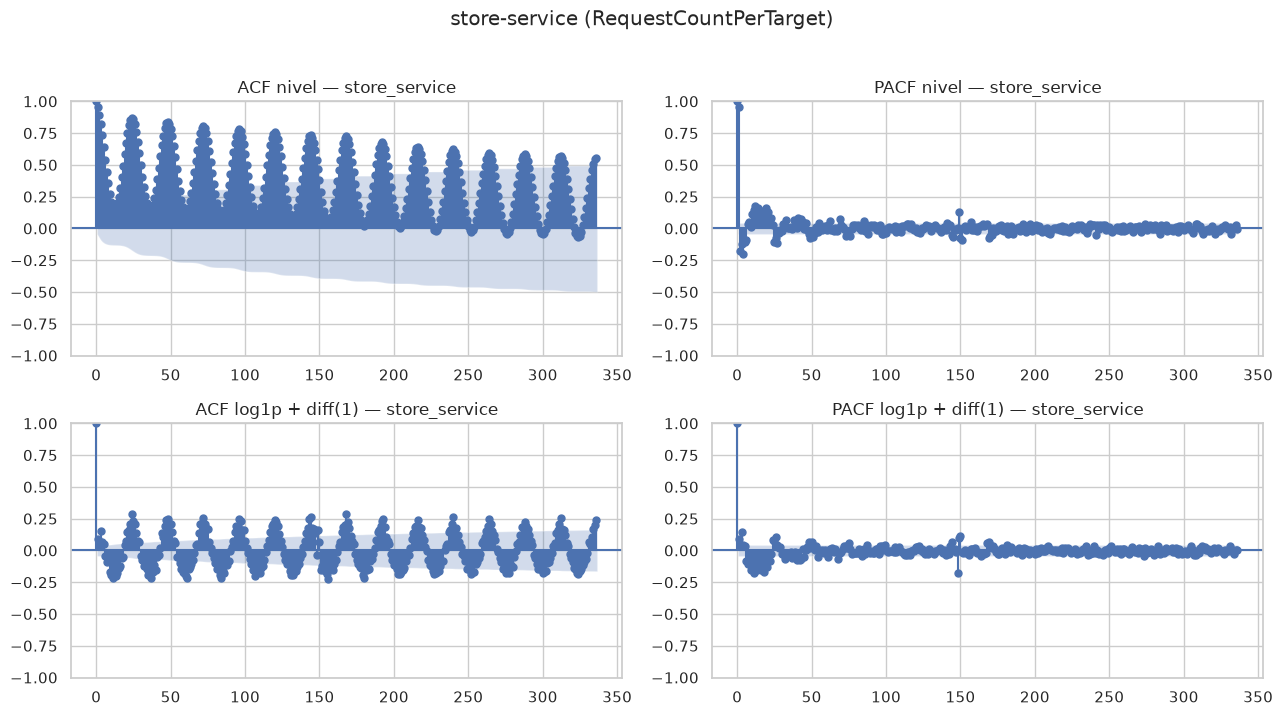

In [7]:
for name in SERIES_NAMES:
    s = clean_series[name]
    log_diff = np.log1p(s).diff().dropna()

    fig, axes = plt.subplots(2, 2, figsize=(13, 7))
    plot_acf(s, lags=336, ax=axes[0, 0], title=f"ACF nivel — {name}")
    plot_pacf(s, lags=336, ax=axes[0, 1], method="ywm", title=f"PACF nivel — {name}")
    plot_acf(log_diff, lags=336, ax=axes[1, 0], title=f"ACF log1p + diff(1) — {name}")
    plot_pacf(log_diff, lags=336, ax=axes[1, 1], method="ywm", title=f"PACF log1p + diff(1) — {name}")
    fig.suptitle(SERIES_LABELS[name], y=1.02)
    fig.tight_layout()
    savefig(fig, f"acf_pacf_{name}")
    plt.show()

En niveles, la ACF decae muy lentamente y muestra picos marcados en múltiplos de 24 (estacionalidad
diaria), consistente con una serie no estacionaria con ciclo diario dominante. Tras aplicar `log1p` y una
diferencia de orden 1, la ACF cae abruptamente y solo persisten picos moderados en los lags múltiplos de 24,
sin estructura relevante en torno al lag 168.

## 7. Estacionariedad: ADF y KPSS en niveles y en primera diferencia

In [8]:
stationarity_rows = []
stationarity_summary = {}
for name in SERIES_NAMES:
    s = clean_series[name]
    log_s = np.log1p(s)
    diff_s = log_s.diff().dropna()

    for label, key, series_ in [("nivel (log1p)", "level", log_s), ("primera diferencia (log1p)", "diff", diff_s)]:
        adf_stat, adf_p, *_ = adfuller(series_, autolag="AIC")
        kpss_stat, kpss_p, *_ = kpss(series_, regression="c", nlags="auto")
        stationarity_rows.append({
            "serie": name, "transformación": label,
            "ADF stat": adf_stat, "ADF p-valor": adf_p,
            "KPSS stat": kpss_stat, "KPSS p-valor": kpss_p,
        })
        stationarity_summary[(name, key)] = {"adf_p": adf_p, "kpss_p": kpss_p}

stationarity_table = pd.DataFrame(stationarity_rows)
stationarity_table

/tmp/ipykernel_188309/2128659850.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series_, regression="c", nlags="auto")
/tmp/ipykernel_188309/2128659850.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series_, regression="c", nlags="auto")
/tmp/ipykernel_188309/2128659850.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series_, regression="c", nlags="auto")
/tmp/ipykernel_188309/2128659850.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value i

,serie,transformación,ADF stat,ADF p-valor,KPSS stat,KPSS p-valor
0,alb,nivel (log1p),-0.829232,8.103842e-01,3.785331,0.01
1,alb,primera diferencia (log1p),-14.761637,2.397228e-27,0.005631,0.10
2,store_service,nivel (log1p),-2.293867,1.739535e-01,5.764898,0.01
3,store_service,primera diferencia (log1p),-12.216130,1.134539e-22,0.006448,0.10


ADF y KPSS son pruebas complementarias: ADF tiene como hipótesis nula la presencia de raíz unitaria (no
estacionariedad), mientras que KPSS tiene como nula la estacionariedad. En niveles se espera no rechazar la
raíz unitaria en ADF (p-valor alto) y rechazar estacionariedad en KPSS (p-valor bajo); tras la primera
diferencia ambos tests deberían coincidir en estacionariedad (ADF p-valor bajo, KPSS p-valor alto). Los
resultados numéricos observados se listan en la tabla y se resumen en la sección 10 y en el documento de
estado de la fase.

## 8. Efecto de feriados (Argentina)

In [9]:
import holidays as holidays_pkg

years = range(clean_series["alb"].index.tz_convert(LOCAL_TZ).year.min(),
              clean_series["alb"].index.tz_convert(LOCAL_TZ).year.max() + 1)
ar_holidays = holidays_pkg.Argentina(years=years)

local_range = clean_series["alb"].index.tz_convert(LOCAL_TZ)
holiday_dates_in_range = sorted({d for d in ar_holidays if local_range.date.min() <= d <= local_range.date.max()})
print("Feriados argentinos en el rango de la serie limpia:", holiday_dates_in_range)

holiday_rows = []
for name in SERIES_NAMES:
    s = clean_series[name]
    local_idx = s.index.tz_convert(LOCAL_TZ)
    for hd in holiday_dates_in_range:
        day_mask = local_idx.date == hd
        if day_mask.sum() == 0:
            continue
        holiday_mean = s[day_mask].mean()
        prev_week_mask = local_idx.date == (hd - pd.Timedelta(days=7))
        if prev_week_mask.sum() == 0:
            continue
        prev_week_mean = s[prev_week_mask].mean()
        holiday_rows.append({
            "serie": name, "feriado": hd,
            "media_feriado": holiday_mean, "media_semana_previa_mismo_dow": prev_week_mean,
            "ratio_%": 100 * holiday_mean / prev_week_mean,
        })

holiday_table = pd.DataFrame(holiday_rows)
holiday_table

Feriados argentinos en el rango de la serie limpia: [datetime.date(2026, 7, 9), datetime.date(2026, 7, 10), datetime.date(2026, 8, 17)]


,serie,feriado,media_feriado,media_semana_previa_mismo_dow,ratio_%
0,alb,2026-07-09,2.330767e+06,2.273142e+06,102.535039
1,alb,2026-07-10,2.375280e+06,2.241739e+06,105.957017
2,alb,2026-08-17,2.226929e+06,2.135335e+06,104.289464
3,store_service,2026-07-09,9.035415e+04,9.841717e+04,91.807309
4,store_service,2026-07-10,8.866874e+04,9.050428e+04,97.971873
5,store_service,2026-08-17,1.076327e+05,9.563962e+04,112.539821


Se comparan los feriados argentinos presentes en el rango limpio contra el mismo día de la semana, una
semana antes (proxy de comportamiento "normal" del mismo día calendario). Un cociente sensiblemente menor a
100&nbsp;% indicaría una reducción de tráfico atribuible al feriado; los valores observados se listan en la
tabla y se retoman en el resumen final.

## 9. Correlación cruzada ALB vs. store_service (serie limpia, diferenciada)

Figura guardada: informe/figuras/01_ccf_alb_store_service.png


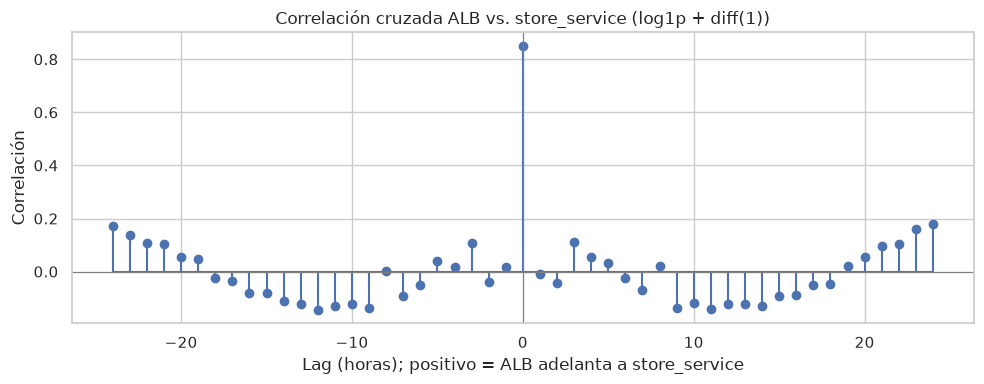

Lag con correlación máxima en valor absoluto: 0 h, corr = 0.852
Correlación en lag 0: 0.852


In [10]:
alb_diff = np.log1p(clean_series["alb"]).diff().dropna()
store_diff = np.log1p(clean_series["store_service"]).diff().dropna()
common_idx = alb_diff.index.intersection(store_diff.index)
alb_diff, store_diff = alb_diff.loc[common_idx], store_diff.loc[common_idx]

max_lag = 24
lags = range(-max_lag, max_lag + 1)
ccf_values = []
for lag in lags:
    if lag >= 0:
        x, y = alb_diff.iloc[: len(alb_diff) - lag if lag else None], store_diff.shift(-lag).dropna()
    else:
        x, y = alb_diff.shift(lag).dropna(), store_diff
    idx = x.index.intersection(y.index)
    ccf_values.append(np.corrcoef(x.loc[idx], y.loc[idx])[0, 1])

ccf_series = pd.Series(ccf_values, index=list(lags))
best_lag = ccf_series.abs().idxmax()

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(ccf_series.index, ccf_series.values)
ax.axvline(0, color="grey", linewidth=0.8)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("Correlación cruzada ALB vs. store_service (log1p + diff(1))")
ax.set_xlabel("Lag (horas); positivo = ALB adelanta a store_service")
ax.set_ylabel("Correlación")
fig.tight_layout()
savefig(fig, "ccf_alb_store_service")
plt.show()

print(f"Lag con correlación máxima en valor absoluto: {best_lag} h, corr = {ccf_series[best_lag]:.3f}")
print(f"Correlación en lag 0: {ccf_series[0]:.3f}")

La correlación cruzada entre las series diferenciadas evalúa si ALB (tráfico total del balanceador)
sirve como variable exógena adelantada para `store_service`. El TP1 había encontrado causalidad de Granger
POS API → ALB (y no en sentido inverso); aquí se repite el análisis con el par ALB / store-service para
verificar la dirección de la relación y elegir el lag más informativo si se decide usar ALB como regresor
exógeno en fases posteriores.

## 10. Resumen final

In [11]:
summary = pd.DataFrame({
    "Métrica": [
        "Rango efectivo (limpio)",
        "Horas totales",
        "Horas de intervención imputadas",
        "Fuerza estacional 24h (ALB)",
        "Fuerza estacional 168h (ALB)",
        "Fuerza estacional 24h (store_service)",
        "Fuerza estacional 168h (store_service)",
        "ADF p-valor / KPSS p-valor, nivel (ALB)",
        "ADF p-valor / KPSS p-valor, diff (ALB)",
        "ADF p-valor / KPSS p-valor, nivel (store_service)",
        "ADF p-valor / KPSS p-valor, diff (store_service)",
        "Lag CCF ALB->store_service (máx |corr|)",
    ],
    "Valor": [
        f"{STEADY_STATE_START} -> {TEST_END}",
        len(clean_series["alb"]),
        int(intervention_mask(clean_series["alb"].index).sum()),
        f"{seasonality_strength['alb']['s24']:.3f}",
        f"{seasonality_strength['alb']['s168']:.3f}",
        f"{seasonality_strength['store_service']['s24']:.3f}",
        f"{seasonality_strength['store_service']['s168']:.3f}",
        f"{stationarity_summary[('alb', 'level')]['adf_p']:.3f} / {stationarity_summary[('alb', 'level')]['kpss_p']:.3f}",
        f"{stationarity_summary[('alb', 'diff')]['adf_p']:.3f} / {stationarity_summary[('alb', 'diff')]['kpss_p']:.3f}",
        f"{stationarity_summary[('store_service', 'level')]['adf_p']:.3f} / {stationarity_summary[('store_service', 'level')]['kpss_p']:.3f}",
        f"{stationarity_summary[('store_service', 'diff')]['adf_p']:.3f} / {stationarity_summary[('store_service', 'diff')]['kpss_p']:.3f}",
        f"{best_lag} h (corr={ccf_series[best_lag]:.3f})",
    ],
})
summary

,Métrica,Valor
0,Rango efectivo (limpio),2026-07-03 00:00:00+00:00 -> 2026-09-26 22:00:...
1,Horas totales,2063
2,Horas de intervención imputadas,116
3,Fuerza estacional 24h (ALB),0.771
4,Fuerza estacional 168h (ALB),0.206
5,Fuerza estacional 24h (store_service),0.846
6,Fuerza estacional 168h (store_service),0.311
7,"ADF p-valor / KPSS p-valor, nivel (ALB)",0.810 / 0.010
8,"ADF p-valor / KPSS p-valor, diff (ALB)",0.000 / 0.100
9,"ADF p-valor / KPSS p-valor, nivel (store_service)",0.174 / 0.010


**Recomendaciones para las fases siguientes:**

- Transformación: `log1p` sobre el nivel, con primera diferencia para estabilizar la media; reportar métricas
  siempre en escala original (consistente con la corrección aplicada en TP1).
- Estacionalidad: modelar el ciclo diario (periodo 24) como componente principal; el periodo semanal (168)
  aporta poco después de julio y puede tratarse como secundario u omitirse sin gran pérdida.
- *Naive* estacional de referencia: `m=24` (no `m=168`, dado que la estacionalidad semanal es prácticamente
  nula), usado también como base de la métrica MASE en la fase 02.
- Variables de calendario: hora local, día de semana, fin de semana y feriados argentinos (efecto medido en
  la sección 8); ALB como posible regresor exógeno de `store_service` según el lag identificado en la
  sección 9.
- La ventana de intervención se imputa para entrenamiento/validación; el conjunto de test de la fase 02
  (2026-09-22 14:00 a 2026-09-26 22:00, 105 h) usa exclusivamente datos observados posteriores al rollback.

## Verificación de integridad

In [12]:
for name in SERIES_NAMES:
    s = clean_series[name]
    assert not s.isna().any(), f"{name}: contiene NaN"
    assert not (s == 0).any(), f"{name}: contiene ceros"
    assert s.index.freq == pd.tseries.frequencies.to_offset("h"), f"{name}: frecuencia no horaria"
    assert s.index[0] == STEADY_STATE_START, f"{name}: inicio inesperado"
    assert s.index[-1] == TEST_END, f"{name}: fin inesperado"

n_intervention = int(intervention_mask(clean_series["alb"].index).sum())
assert n_intervention == 116, f"Se esperaban 116 horas de intervención, se obtuvieron {n_intervention}"

print("Todas las verificaciones de integridad pasaron correctamente.")

Todas las verificaciones de integridad pasaron correctamente.
